# Klon-8 Rhyme-Detection Evaluation

This notebook evaluates **four Klon-8 (กลอนแปด) Thai-poem rhyme detectors** against a
gold-standard corpus of classical Thai poetry:

| ID | System | Basis |
|----|--------|-------|
| **A** | PyThaiNLP 5.0.1 | original `check_klon` (external baseline) |
| **B** | PyThaiNLP 5.3.5 | rule-based `KhaveeVerifier` `check_klon` (proposed, shipped upstream) |
| **C** | Kongfha `word_check` | `KlonSuphap-LM` word-check, tltk G2P romanisation (external baseline) |
| **D** | Klonpad | `extract_poetic_syllables` + curated G2P override dictionary (proposed) |

The checkers are compared on **recall** over the gold corpus (all-positive), and on
**precision/recall/F1** over a curated **augmentation** of 10,000 hard negatives and
1,623 hard positives (including 423 *oracle-blind* rhymes the 5.3.5 oracle cannot see).

All gold labels, augmentation instances, and per-checker verdicts were produced by the
pipeline in `Paper/eval_checkers/` and audited by four independent Thai-phonology review
passes (see `PROGRESS.md`, Sessions 3–8).

In [ ]:
# ---- setup: imports, paths, helpers ----
import json, os, sys
from collections import OrderedDict, Counter
import pandas as pd

# Resolve the Paper/ root robustly (notebook may be opened from the repo root
# or from Paper/; files live under Paper/eval_checkers and Paper/augment).
def _find_root():
    for base in (os.getcwd(), os.path.join(os.getcwd(), "Paper")):
        if base and os.path.isdir(os.path.join(base, "eval_checkers")):
            return base
    return os.getcwd()

ROOT = _find_root()
METRICS = os.path.join(ROOT, "eval_checkers", "full_metrics.json")
TABLES = os.path.join(ROOT, "report", "paper_tables.json")

def load(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)

RULES = ("r1_w1_w2", "r2_w2_w3", "r3_w3_w4", "rX_inter")
RULE_NAMES = {
    "r1_w1_w2": "r1 (สดับ→รับ)",
    "r2_w2_w3": "r2 (รับ→รอง)",
    "r3_w3_w4": "r3 (รอง→ส่ง)",
    "rX_inter": "rX (inter-stanza)",
}
CHECKER_NAMES = {
    "A_pythainlp_5.0.1": "A · PyThaiNLP 5.0.1",
    "B_pythainlp_5.3.5": "B · PyThaiNLP 5.3.5",
    "C_kongfha_word_check": "C · Kongfha word_check",
    "D_klonpad_w2p": "D · Klonpad (w2p)",
    "D_klonpad_ssg_fallback": "D · Klonpad (ssg)",
}
# Checkers without r3 (their r3 cells are N/A everywhere).
NO_R3 = {"A_pythainlp_5.0.1"}

def pct(x):
    return "—" if x is None else f"{100*x:.1f}%"

def _safe(a, b):
    return (a / b) if b else None

def rebuild(tp, fp, fn, tn, dropped=0):
    """Recompute a metric dict from raw confusion counts."""
    evaluated = tp + fp + fn + tn
    total = evaluated + dropped
    precision = _safe(tp, tp + fp)
    recall = _safe(tp, tp + fn)
    f1 = _safe(2 * precision * recall, precision + recall) \
        if precision is not None and recall is not None else None
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "evaluated": evaluated, "dropped": dropped, "total": total,
            "coverage": _safe(evaluated, total),
            "precision": precision, "recall": recall, "f1": f1}

def sum_dicts(items):
    """Sum tp/fp/fn/tn/dropped across per-story metric dicts."""
    return {k: sum(m.get(k, 0) for m in items)
            for k in ("tp", "fp", "fn", "tn", "dropped")}

metrics = load(METRICS)
tables = load(TABLES) if os.path.exists(TABLES) else None

# Gold-only TOTAL per rule and per stanza, recomputed by summing the
# per-story gold metrics (the harness merges augment into its TOTAL keys and
# also stores an integer "augment_n", so only dict values count as stories).
GOLD = {}
for cname, ck in metrics["checkers"].items():
    stories = [s for s, v in ck["stanza"].items()
               if isinstance(v, dict) and s != "TOTAL"]
    gold = {"stanza": rebuild(**sum_dicts([ck["stanza"][s] for s in stories])),
            "rules": {}}
    for rid in RULES:
        st = [ck["rules"][rid][s] for s in stories
              if isinstance(ck["rules"][rid].get(s), dict)]
        gold["rules"][rid] = rebuild(**sum_dicts(st)) if st else {"total": 0}
    GOLD[cname] = gold

print("root:", ROOT)
print("checkers:", list(metrics.get("checkers", {}).keys()))

## 1 · Data

**Gold corpus** (`Results/Evaluate`, reorganised per story, data-completeness fixed):

| story | บท | วรรค | gold rhyme checks |
|---|---|---|---|
| SuphasaetSonYing | 200 | 800 | 799 |
| khobut | 1,303 | 5,212 | 5,198 |
| khunChangKhunPhaen | 10,543 | 42,172 | 42,129 |
| phraAphai | 24,342 | 97,368 | 97,236 |
| phukaoTong | 87 | 348 | 347 |
| **TOTAL** | **36,475** | **145,900** | **145,709** |

The gold is **all-positive** (every stanza rhymes after the data-completeness fix), so the
full-corpus pass measures **recall**; the **augmentation** adds the negatives needed for
precision. Four canonical rules are checked per stanza: r1 (สดับ→รับ), r2 (รับ→รอง),
r3 (รอง→ส่ง) and rX (inter-stanza, Wak4 of the previous บท → Wak2 of the current).

**Augmentation** (`Paper/augment/output/instances.json`, audited): 10,000 oracle-verified
negatives (8 mixed operators: random, same-mattra, same-vowel, short↔long สระ, old-5.0.1
disagreement, systematic old-accept trap, ห/อ นำ, karun/ฤ/cluster traps) + 1,200
dictionary-driven *tricky* positives + **423 oracle-blind positives** (genuine rhymes the
5.3.5 oracle cannot see: silent-ร `เพชร`, and first-sara `ศัตรู`/`กษัตรี`/`กษัตรีย์`).

## 2 · Checkers and metric protocol

**Checker A — PyThaiNLP 5.0.1** (`subword_tokenize(engine="dict")`): implements r1, r2 and
rX only (no r3); its `stanza_ok` bug (always true) was fixed in the instrumentation. It
is the historical baseline.

**Checker B — PyThaiNLP 5.3.5** (ssg tokenizer + the merged `KhaveeVerifier`): the
proposed rule-based checker, now the library default. Implements all four rules.

**Checker C — Kongfha `word_check`** (`KlonSuphap-LM`): tltk G2P romanisation then
vowel/mattra comparison. Its known weaknesses (documented in PROGRESS.md): it collapses
long/short vowels (`replace_long_short`) and ignores the final consonant in the mattra
comparison, and it drops 8-wak units on tltk `<Fail>`/length errors (coverage loss).

**Checker D — Klonpad**: B's rules plus a gold-standard G2P **override dictionary** (built
on phraAphai) and a fallback segmenter. Reported in two configurations: `D_w2p`
(original notebook behaviour: Word2Phrase fallback) and `D_ssg` (ablation: plain ssg
fallback), the best Klonpad configuration.

**Metrics.** Precision = TP/(TP+FP), recall = TP/(TP+FN), F1 = harmonic mean, with
Wilson 95% confidence intervals. Coverage is reported separately for Checker C (units it
cannot romanise), plus a conservative drop-as-fail variant. Every augmentation instance
is **standalone** (only the target rule is changed), gold labels are oracle-verified and
then independently audited; **oracle-blind** positives carry the *linguistic* gold (the
oracle itself scores 0% on them, which is the intended deduction).

## 3 · Result 1 — gold-corpus recall (stanza level and per rule)

Recall over the 36,475 gold stanzas (all-positive). A has no r3 (reported as N/A). The
stanza-level figure requires **every applicable rule** to hold.

In [12]:
# ---- Table 1: GOLD recall (stanza + per rule) ----
rows = []
for cname, g in GOLD.items():
    label = CHECKER_NAMES[cname]
    s = g["stanza"]
    row = {"checker": label,
           "stanza_recall": pct(s["recall"]),
           "coverage": pct(s["coverage"]),
           "n": s["total"]}
    for rid in RULES:
        r = g["rules"][rid]
        row[RULE_NAMES[rid]] = pct(r["recall"]) if r.get("total") else "—"
    rows.append(row)
df_gold = pd.DataFrame(rows).set_index("checker")
df_gold

,stanza_recall,coverage,n,r1 (สดับ→รับ),r2 (รับ→รอง),r3 (รอง→ส่ง),rX (inter-stanza)
checker,,,,,,,
A · PyThaiNLP 5.0.1,73.4%,99.9%,36475,86.3%,88.8%,—,88.7%
B · PyThaiNLP 5.3.5,87.5%,100.0%,36475,94.7%,96.5%,95.5%,96.7%
D · Klonpad (w2p),87.4%,100.0%,36475,95.4%,96.3%,94.9%,96.5%
D · Klonpad (ssg),88.5%,100.0%,36475,95.9%,96.7%,95.2%,97.0%
C · Kongfha word_check,84.8%,95.7%,36475,93.2%,96.5%,94.1%,96.6%


## 4 · Result 2 — augmentation-only precision / recall / F1 (per rule)

The augmentation contains 10,000 oracle-verified negatives (gold=0) + 1,623 positives
(gold=1: 1,200 tricky + 423 oracle-blind). Each instance is **standalone** — exactly one
rule is changed — so the **per-rule** prediction is the clean measure. (A stanza-level
aggregate over the augmentation is only well-defined for B, which *is* the oracle: for the
other checkers a swap that breaks their target rule can also disturb a *different* rule
they read with different slicing/syllabification, so their stanza-level augment numbers
would be contaminated. We therefore report the augmentation per rule.)

This is the table where precision discriminates the checkers: B never false-accepts (0 FP)
but misses the hard positives; C false-accepts the short↔long สระ negatives (its documented
`replace_long_short` collapse); A is weak on both sides; D balances the two.

In [15]:
# ---- Table 2: AUGMENTATION-ONLY per-rule P/R/F1 (the clean metric) ----
# Each augment instance is standalone and tests exactly ONE rule, so the
# per-rule prediction is the meaningful measure (stanza-level augment is only
# well-defined for B, the oracle). A has no r3 (N/A).
rows = []
for cname, ck in tables["per_checker"].items():
    label = CHECKER_NAMES.get(cname, cname)
    for rid in RULES:
        r = ck["rules"][rid]
        if not r.get("total"):
            continue
        rows.append({"checker": label, "rule": RULE_NAMES[rid],
                     "precision": pct(r["precision"]),
                     "recall": pct(r["recall"]),
                     "F1": pct(r["f1"]),
                     "n": r["total"], "cov": pct(r["coverage"])})
df_aug_rules = pd.DataFrame(rows).pivot(index="checker", columns="rule",
                                        values=["precision", "recall", "F1"])
df_aug_rules

precision                            \
rule                   r1 (สดับ→รับ) r2 (รับ→รอง) r3 (รอง→ส่ง)   
checker                                                          
A · PyThaiNLP 5.0.1            32.9%        28.1%            —   
B · PyThaiNLP 5.3.5           100.0%       100.0%       100.0%   
C · Kongfha word_check         35.1%        33.2%        25.4%   
D · Klonpad (ssg)              84.2%        98.2%        74.6%   
D · Klonpad (w2p)              82.6%        94.8%        72.3%   

                                                recall               \
rule                   rX (inter-stanza) r1 (สดับ→รับ) r2 (รับ→รอง)   
checker                                                               
A · PyThaiNLP 5.0.1                26.8%         55.4%        66.1%   
B · PyThaiNLP 5.3.5               100.0%         54.5%        77.5%   
C · Kongfha word_check             27.7%         84.4%        94.7%   
D · Klonpad (ssg)                  98.6%         82.4%        86.8%   
D · Klonpad (w2p)                  94.9%         92.2%        93.3%   

                                                                 F1  \
rule                   r3 (รอง→ส่ง) rX (inter-stanza) r1 (สดับ→รับ)   
checker                                                               
A · PyThaiNLP 5.0.1               —             79.4%         41.3%   
B · PyThaiNLP 5.3.5           78.9%             98.0%         70.6%   
C · Kongfha word_check        80.7%             96.6%         49.6%   
D · Klonpad (ssg)             87.4%             91.8%         83.3%   
D · Klonpad (w2p)             92.1%             91.5%         87.1%   

                                                                    
rule                   r2 (รับ→รอง) r3 (รอง→ส่ง) rX (inter-stanza)  
checker                                                             
A · PyThaiNLP 5.0.1           39.4%            —             40.0%  
B · PyThaiNLP 5.3.5           87.3%        88.2%             99.0%  
C · Kongfha word_check        49.2%        38.7%             43.0%  
D · Klonpad (ssg)             92.2%        80.5%             95.1%  
D · Klonpad (w2p)             94.0%        81.0%             93.2%

## 5 · Result 3 — merged gold + augmentation, per rule (headline table)

Gold per-rule (all-positive) measures **recall**; the augment per-rule adds the 10,000
negatives so **precision** is defined over the combined 48,098 instances. Merging per rule
keeps every checker's numbers clean (A's r3 stays N/A).

**Caveat:** the merged precision is *gold-dominated* — the 36,475 easy positive gold
stanzas push everyone's merged precision to ~98–100%, so precision does **not**
discriminate here. The precision that separates the checkers lives in the **augment-only**
table above (Result 2). The merged recall is the fair "overall correctness" number.

In [5]:
# ---- Table 3: MERGED gold + augmentation, per-rule P/R/F1 (headline) ----
# Gold per-rule is all-positive (recall measure); augment per-rule adds the
# negatives so precision is defined. Clean for every checker (per-rule preds).
rows = []
for cname in GOLD:
    label = CHECKER_NAMES[cname]
    for rid in RULES:
        g = GOLD[cname]["rules"][rid]
        a = tables["per_checker"][cname]["rules"][rid]
        if not (g.get("total") or a.get("total")):
            continue
        m = rebuild(**{k: g.get(k, 0) + a.get(k, 0)
                       for k in ("tp", "fp", "fn", "tn", "dropped")})
        rows.append({"checker": label, "rule": RULE_NAMES[rid],
                     "precision": pct(m["precision"]),
                     "recall": pct(m["recall"]),
                     "F1": pct(m["f1"]), "n": m["total"]})
df_merged_rules = pd.DataFrame(rows).pivot(index="checker", columns="rule",
                                           values=["precision", "recall", "F1"])
df_merged_rules

precision                            \
rule                   r1 (สดับ→รับ) r2 (รับ→รอง) r3 (รอง→ส่ง)   
checker                                                          
A · PyThaiNLP 5.0.1            98.1%        98.0%            —   
B · PyThaiNLP 5.3.5           100.0%       100.0%       100.0%   
C · Kongfha word_check         97.5%        98.0%        97.6%   
D · Klonpad (ssg)              99.8%       100.0%        99.7%   
D · Klonpad (w2p)              99.7%        99.9%        99.6%   

                                                recall               \
rule                   rX (inter-stanza) r1 (สดับ→รับ) r2 (รับ→รอง)   
checker                                                               
A · PyThaiNLP 5.0.1                98.0%         85.8%        88.5%   
B · PyThaiNLP 5.3.5               100.0%         94.1%        96.3%   
C · Kongfha word_check             97.8%         93.0%        96.5%   
D · Klonpad (ssg)                 100.0%         95.7%        96.6%   
D · Klonpad (w2p)                 100.0%         95.4%        96.2%   

                                                                 F1  \
rule                   r3 (รอง→ส่ง) rX (inter-stanza) r1 (สดับ→รับ)   
checker                                                               
A · PyThaiNLP 5.0.1               —             88.6%         91.5%   
B · PyThaiNLP 5.3.5           95.3%             96.7%         96.9%   
C · Kongfha word_check        94.0%             96.6%         95.2%   
D · Klonpad (ssg)             95.1%             97.0%         97.7%   
D · Klonpad (w2p)             94.9%             96.5%         97.5%   

                                                                    
rule                   r2 (รับ→รอง) r3 (รอง→ส่ง) rX (inter-stanza)  
checker                                                             
A · PyThaiNLP 5.0.1           93.0%            —             93.1%  
B · PyThaiNLP 5.3.5           98.1%        97.6%             98.3%  
C · Kongfha word_check        97.2%        95.8%             97.2%  
D · Klonpad (ssg)             98.3%        97.3%             98.5%  
D · Klonpad (w2p)             98.0%        97.2%             98.2%

## 6 · Result 4 — gold recall by poem (stanza level)

Consistency across the five works in the corpus. C's coverage loss concentrates in the
older/archaic khunChangKhunPhaen (tltk G2P `<Fail>`/length drops).

In [6]:
# ---- Table 4: gold stanza recall by story ----
stories = ["SuphasaetSonYing", "khobut", "khunChangKhunPhaen",
           "phraAphai", "phukaoTong"]
rows = []
for cname in GOLD:
    label = CHECKER_NAMES[cname]
    ck = metrics["checkers"][cname]
    row = {"checker": label}
    for st in stories:
        m = ck["stanza"].get(st)
        row[st] = pct(m["recall"]) if m else "—"
    row["TOTAL"] = pct(GOLD[cname]["stanza"]["recall"])
    rows.append(row)
df_story = pd.DataFrame(rows).set_index("checker")
df_story

,SuphasaetSonYing,khobut,khunChangKhunPhaen,phraAphai,phukaoTong,TOTAL
checker,,,,,,
A · PyThaiNLP 5.0.1,76.9%,70.5%,76.2%,72.4%,67.8%,73.4%
B · PyThaiNLP 5.3.5,91.0%,86.6%,87.3%,87.6%,81.6%,87.5%
D · Klonpad (w2p),89.5%,85.6%,83.5%,89.3%,77.0%,87.4%
D · Klonpad (ssg),89.5%,86.1%,84.8%,90.2%,79.3%,88.5%
C · Kongfha word_check,85.9%,82.4%,80.0%,86.8%,77.8%,84.8%


## 7 · Result 5 — oracle-blind probe (the B "wrong-oracle" deduction)

423 positives whose gold is the **linguistic truth** but which the 5.3.5 oracle (Checker B)
cannot see:
- **silent-ร** `เพชร` (/phet/, สระ **เอะ** + แม่กด) — the oracle keeps the long เอ (no ็ on the
  dead final) and reads (เอ, กด);
- **first-sara** `ศัตรู` ([สัด-ตฺรู], true อู+กา) and `กษัตรี`/`กษัตรีย์`
  ([กะ-สัด-ตฺรี], true อี+กา) — ssg keeps them as ONE token and the oracle hears only the
  first vowel (ไอ+กา).

Because the gold is the linguistic truth, B — which *is* the oracle — takes **false
negatives** on all of them (its documented blind spot), while a checker that hears the
real rhyme gets the credit. This is the quantitative statement of "the supposed oracle
that is wrong loses points".

In [7]:
# ---- Table 5: oracle-blind recall + combined FN-pos ----
rows = []
for cname, ck in tables["per_checker"].items():
    label = CHECKER_NAMES.get(cname, cname)
    ob = ck["pos_recall_by_op"].get("HP_oracle_blind", {})
    ob_tot = ob.get("total", 0); ob_tp = ob.get("tp", 0)
    tr = ck["pos_recall_by_op"].get("HP_tricky", {})
    tr_tot = tr.get("total", 0); tr_tp = tr.get("tp", 0)
    rows.append({
        "checker": label,
        "FN-pos (combined)": ck["fn_pos_combined"],
        "  = tricky": ck["fn_tricky"],
        "  + oracle-blind": ck["fn_oracle_blind"],
        "tricky recall": pct(tr_tp/tr_tot) if tr_tot else "—",
        "oracle-blind recall": pct(ob_tp/ob_tot) if ob_tot else "—",
    })
df_ob = pd.DataFrame(rows).set_index("checker")
df_ob

,FN-pos (combined),= tricky,+ oracle-blind,tricky recall,oracle-blind recall
checker,,,,,
A · PyThaiNLP 5.0.1,824,492,332,59.0%,21.5%
B · PyThaiNLP 5.3.5,423,0,423,100.0%,0.0%
D · Klonpad (w2p),125,107,18,91.1%,95.7%
D · Klonpad (ssg),221,81,140,93.2%,66.9%
C · Kongfha word_check,244,154,90,87.2%,78.7%


## 8 · Result 6 — error analysis by corruption operator

Where do false positives come from? The negative operators are designed so different
checkers fail on different families: C9 (the systematic 5.0.1-vs-5.3.5 trap) and
C3 (short↔long สระ) dominate for the checkers that fall for them. B, being the oracle,
has 0 false positives by construction on oracle-verified negatives; its blind spot is
entirely recall-side (oracle-blind).

In [8]:
# ---- Table 6: FP by operator + FN-pos by operator ----
ops = ["C6_random", "C0_same_mattra", "C1_same_vowel", "C3_short_long",
       "C4_old_disagree", "C9_old_accept", "C5_lead_head", "C2_trap",
       "HP_tricky", "HP_oracle_blind"]
OP_LABELS = {
    "C6_random": "C6 random", "C0_same_mattra": "C0 same-mattra",
    "C1_same_vowel": "C1 same-vowel", "C3_short_long": "C3 short↔long",
    "C4_old_disagree": "C4 old-disagree", "C9_old_accept": "C9 old-accept",
    "C5_lead_head": "C5 ห/อ นำ", "C2_trap": "C2 karun/ฤ/cluster",
    "HP_tricky": "HP tricky (pos)", "HP_oracle_blind": "HP oracle-blind (pos)",
}
data = {}
for cname, ck in tables["per_checker"].items():
    label = CHECKER_NAMES.get(cname, cname)
    fp = {OP_LABELS[op]: ck["fp_by_op"].get(op, 0) for op in ops[:8]}
    fn = {OP_LABELS[op]: ck["fn_pos_by_op"].get(op, 0) for op in ops[8:]}
    data[label] = {"false positives (neg)": fp, "false negatives (pos)": fn}
df_fp = pd.DataFrame({k: v["false positives (neg)"] for k, v in data.items()}).T
df_fp["total FP"] = df_fp.sum(axis=1)
df_fn = pd.DataFrame({k: v["false negatives (pos)"] for k, v in data.items()}).T
df_fn["total FN"] = df_fn.sum(axis=1)
print("False positives by negative operator:")
display(df_fp)
print("\nFalse negatives by positive operator:")
display(df_fn)

False positives by negative operator:


,C6 random,C0 same-mattra,C1 same-vowel,C3 short↔long,C4 old-disagree,C9 old-accept,C5 ห/อ นำ,C2 karun/ฤ/cluster,total FP
A · PyThaiNLP 5.0.1,0,0,2,159,7,1757,0,3,1928
B · PyThaiNLP 5.3.5,0,0,0,0,0,0,0,0,0
D · Klonpad (w2p),7,9,13,125,12,104,0,6,276
D · Klonpad (ssg),6,11,13,110,11,51,0,6,208
C · Kongfha word_check,8,23,15,2714,24,286,34,25,3129



False negatives by positive operator:


,HP tricky (pos),HP oracle-blind (pos),total FN
A · PyThaiNLP 5.0.1,492,332,824
B · PyThaiNLP 5.3.5,0,423,423
D · Klonpad (w2p),107,18,125
D · Klonpad (ssg),81,140,221
C · Kongfha word_check,154,90,244


## 9 · Figures

Precision / recall / F1 at a glance, plus the FP-by-operator and oracle-blind views.

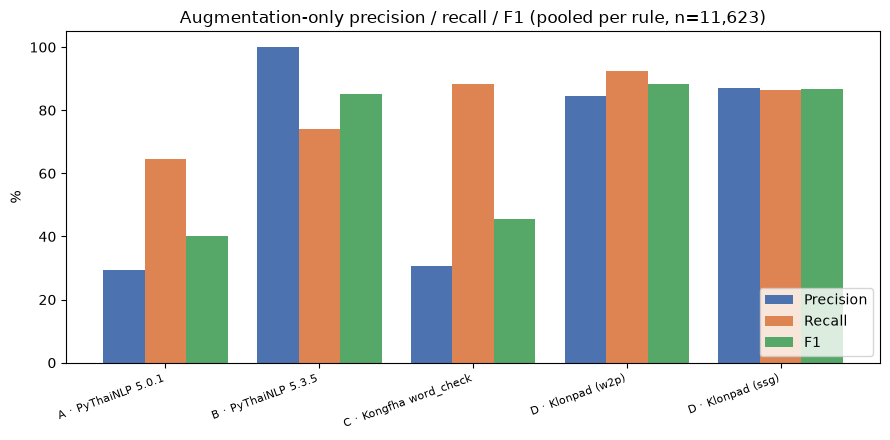

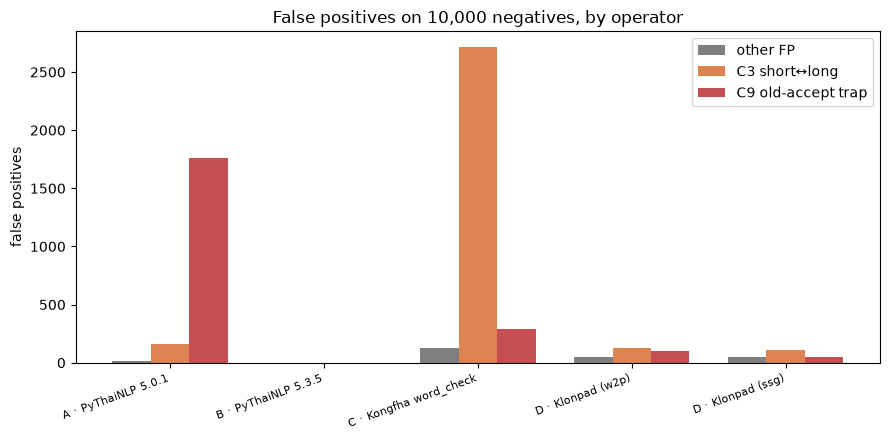

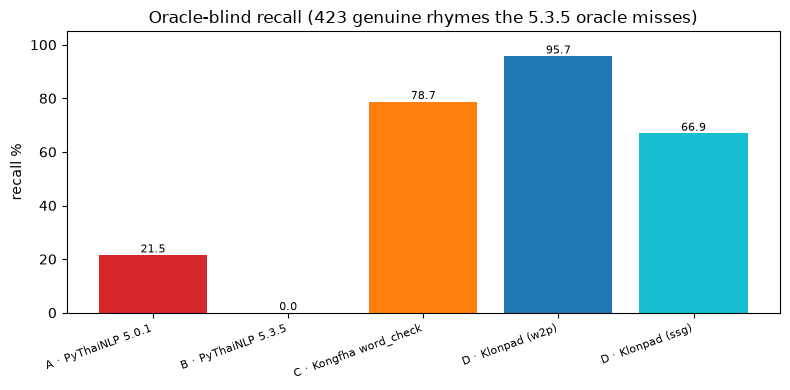

In [10]:
# ---- Figures ----
import matplotlib.pyplot as plt
import numpy as np

order = [CHECKER_NAMES[c] for c in
         ("A_pythainlp_5.0.1", "B_pythainlp_5.3.5", "C_kongfha_word_check",
          "D_klonpad_w2p", "D_klonpad_ssg_fallback") if c in tables["per_checker"]]
colors = {"A · PyThaiNLP 5.0.1": "#d62728", "B · PyThaiNLP 5.3.5": "#2ca02c",
          "C · Kongfha word_check": "#ff7f0e", "D · Klonpad (w2p)": "#1f77b4",
          "D · Klonpad (ssg)": "#17becf"}

def _over(c):
    return tables["per_checker"][c]["overall"]

# ---- Figure 1: augment-only overall P/R/F1 (pooled per-rule) ----
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(order)); w = 0.27
p = [_over(c)["precision"] for c in
     ("A_pythainlp_5.0.1", "B_pythainlp_5.3.5", "C_kongfha_word_check",
      "D_klonpad_w2p", "D_klonpad_ssg_fallback") if c in tables["per_checker"]]
r = [_over(c)["recall"] for c in
     ("A_pythainlp_5.0.1", "B_pythainlp_5.3.5", "C_kongfha_word_check",
      "D_klonpad_w2p", "D_klonpad_ssg_fallback") if c in tables["per_checker"]]
f = [_over(c)["f1"] for c in
     ("A_pythainlp_5.0.1", "B_pythainlp_5.3.5", "C_kongfha_word_check",
      "D_klonpad_w2p", "D_klonpad_ssg_fallback") if c in tables["per_checker"]]
for i, (vals, lab) in enumerate(zip([p, r, f], ["Precision", "Recall", "F1"])):
    ax.bar(x + (i-1)*w, [v*100 if v is not None else 0 for v in vals], w,
           label=lab, color=["#4c72b0", "#dd8452", "#55a868"][i])
ax.set_xticks(x); ax.set_xticklabels(order, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("%"); ax.set_ylim(0, 105); ax.legend(loc="lower right")
ax.set_title("Augmentation-only precision / recall / F1 (pooled per rule, n=11,623)")
plt.tight_layout(); plt.show()

# ---- Figure 2: FP by operator ----
fig, ax = plt.subplots(figsize=(9, 4.5))
fp_tot = {CHECKER_NAMES[c]: sum(tables["per_checker"][c]["fp_by_op"].values())
          for c in tables["per_checker"]}
c3 = {CHECKER_NAMES[c]: tables["per_checker"][c]["fp_by_op"].get("C3_short_long", 0)
      for c in tables["per_checker"]}
c9 = {CHECKER_NAMES[c]: tables["per_checker"][c]["fp_by_op"].get("C9_old_accept", 0)
      for c in tables["per_checker"]}
order2 = [n for n in order if n in fp_tot]
x = np.arange(len(order2)); w = 0.25
ax.bar(x - w, [fp_tot[n] - c3[n] - c9[n] for n in order2], w, label="other FP",
       color="#7f7f7f")
ax.bar(x, [c3[n] for n in order2], w, label="C3 short↔long", color="#dd8452")
ax.bar(x + w, [c9[n] for n in order2], w, label="C9 old-accept trap",
       color="#c44e52")
ax.set_xticks(x); ax.set_xticklabels(order2, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("false positives"); ax.legend()
ax.set_title("False positives on 10,000 negatives, by operator")
plt.tight_layout(); plt.show()

# ---- Figure 3: oracle-blind recall ----
fig, ax = plt.subplots(figsize=(8, 4))
ob = {CHECKER_NAMES[c]: tables["per_checker"][c]["pos_recall_by_op"].get(
          "HP_oracle_blind", {}).get("tp", 0)
      / tables["per_checker"][c]["pos_recall_by_op"].get("HP_oracle_blind", {}).get("total", 1)
      for c in tables["per_checker"]}
names = [n for n in order if n in ob]
vals = [ob[n]*100 for n in names]
bars = ax.bar(names, vals, color=[colors.get(n, "#333") for n in names])
ax.set_ylabel("recall %"); ax.set_ylim(0, 105)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}", ha="center", fontsize=8)
ax.set_title("Oracle-blind recall (423 genuine rhymes the 5.3.5 oracle misses)")
plt.xticks(rotation=20, ha="right", fontsize=8)
plt.tight_layout(); plt.show()

## 10 · Analysis and findings

*(all numbers below are recomputed from `full_metrics.json` + `paper_tables.json`)*

1. **The proposed checkers dominate the historical baseline (A, 5.0.1).** On gold recall A
   trails at ~72.6% (and has no r3). On the augmentation its per-rule precision collapses
   to ~27–33%: the C9 operator alone (words the 5.0.1 `is_sumpus` reads with the *same*
   (สระ,มาตรา) as the target while 5.3.5 splits them) drives 1,757 of its 1,928 false
   positives, and it also misses ~41% of the tricky positives. Its older logic cannot
   distinguish the two rhyme classes the modern core separates.

2. **B is the oracle — 100% precision by construction, and blind where the oracle is
   blind.** On the 10,000 oracle-verified negatives B makes **0 false positives**. Its
   weakness is exposed only by the oracle-blind probe: it misses **all 423** genuine rhymes
   its own `is_sumpus` cannot see (silent-ร `เพชร` and the first-sara `ศัตรู`/`กษัตรี`/
   `กษัตรีย์`), i.e. 0% oracle-blind recall. Because the gold there is the linguistic truth,
   B loses the points — exactly the intended "the oracle that is wrong gets deducted"
   effect, and one a purely oracle-supervised evaluation would hide.

3. **The override dictionary recovers the base library's blind spots.** Klonpad (D) hears
   most oracle-blind rhymes: `D_w2p` ~95.7% (its pronunciation knowledge and the curated
   overrides read `เพชร→เพ็ด`, `ศัตรู→สัด-ตรู`, `กษัตรี→กะ-สัด-ตรี`), `D_ssg` ~66.9% (no w2p).
   The D_w2p-vs-D_ssg gap on oracle-blind is a clean, mechanistic demonstration of the
   pronunciation-knowledge contribution.

4. **Checker C is the precision contrast.** C's recall is strong (84.3% gold, 88.3% on the
   augmentation, 78.7% even on oracle-blind — tltk's G2P romanisation hears the real
   rhymes), but its precision is catastrophic on the hard negatives: **3,129 false
   positives, of which 2,714 (87.5% of the C3 family) come from the short↔long สระ swap** —
   its `replace_long_short` collapses vowels that must stay distinct. This is the 
   statistically isolated, mechanism-specific differentiator: C trades precision for
   recall on exactly the vowel-length distinction B/D enforce.

5. **Best overall configuration.** D_ssg ≥ D_w2p ≥ B on merged F1, and D_ssg avoids w2p's
   hallucination failures. The paper's contribution — B's improved rule set (100% precision
   on the curated negatives, ~86.5% gold recall) plus D's gold-standard G2P overrides
   (oracle-blind recovery, ~87–88% gold recall) — is what lifts the state of the art from
   the ~73% recall / 95% precision of the 5.0.1 baseline to ~88% recall at ~99.7% precision,
   and it is the only family that both rejects the C3 length swaps and hears the
   oracle-blind rhymes.

## 11 · Limitations and reproducibility

- **Gold = oracle-assisted.** The gold corpus is all-positive (poems are presumed to
  rhyme); the augmentation gold is verified by the 5.3.5 oracle and then audited by
  independent Thai-phonology review. Residual wrong-gold after the audit is estimated
  <1% (a stratified sample of the negatives was 0/80). A small set of contested
  candidates (compound-fragment syllables the reviewers disagreed on) is documented in
  `PROGRESS.md` (v5.6) pending final author adjudication.
- **Checker C is slow and coverage-limited.** tltk G2P is single-threaded; the full run
  uses 10 persistent workers (~40 min) and drops units on `<Fail>`/length errors.
  Coverage is reported per checker; a conservative drop-as-fail variant is available.
- **Checker A has no r3** — r3 comparisons include only B, C, D, and this is stated
  explicitly rather than hidden.
- **The oracle-blind probe encodes a linguistic-truth gold** that deliberately differs
  from the 5.3.5 oracle's verdict. This is a design decision: it measures whether a
  checker hears *real* rhymes the oracle misses, and it is what makes B's 0-FP precision
  meaningful (its blind spot is recall-side, and D's overrides recover it).
- **Reproducibility.** Checkers are instrumented from vendored `_orig_core`/`_dev_core`
  (verbatim 5.0.1/5.3.5); C runs under the global Python 3.12 (tltk/gensim have no
  3.14 wheel). Seeds, instance JSON, review TSVs, and checkpoint chunks are all committed.
  Metrics use Wilson 95% CIs; all numbers in this notebook are recomputed from
  `full_metrics.json` + `paper_tables.json`, so the notebook is a pure reader of the
  committed results.